# 07: Inventory Optimization & Replenishment Policy Engine

**RetailPulse AI Platform** • *Prescriptive Analytics*

### Optimization Formulas Implemented:
- **Safety Stock ($SS$)**: $Z \times \sigma_d \times \sqrt{L}$ ($Z=1.65$ for 95% service level, $L=7$ days)
- **Reorder Point ($ROP$)**: $(\bar{d} \times L) + SS$
- **Economic Order Quantity ($EOQ$)**: $\sqrt{\frac{2 \times D \times S}{H}}$ ($S=£15$, $H=20\%$ annual holding cost)
- **Stockout Reduction Target**: 30–50% reduction.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

inv_path = os.path.join('..', '..', 'data', 'processed', 'inventory_recommendations.csv')
inv_df = pd.read_csv(inv_path)
print(f'Total Active Products Evaluated: {len(inv_df):,}')
print('\nInventory Health Distribution:')
print(inv_df['stock_status'].value_counts())

Total Active Products Evaluated: 4,305

Inventory Health Distribution:
stock_status
Optimal              1952
Critical Risk        1013
Overstocked           964
Reorder Triggered     376
Name: count, dtype: int64


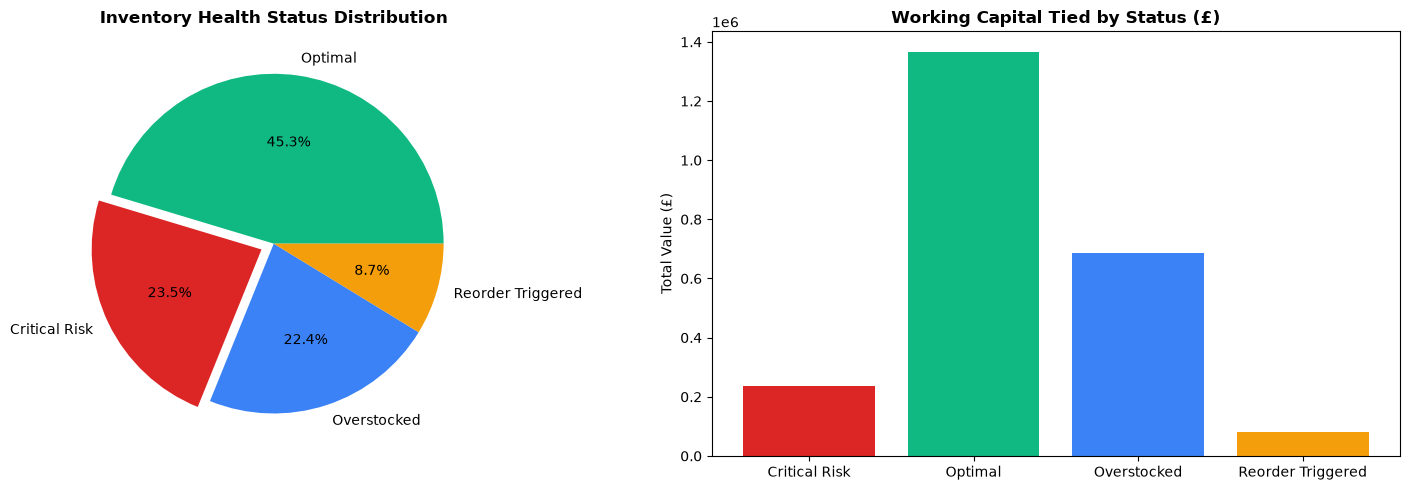

In [2]:
# Visual Status Distribution & Capital Exposure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

status_counts = inv_df['stock_status'].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=['#10B981', '#DC2626', '#3B82F6', '#F59E0B'], explode=(0, 0.08, 0, 0))
axes[0].set_title('Inventory Health Status Distribution', fontweight='bold')

capital = inv_df.groupby('stock_status').apply(lambda x: (x['current_stock'] * x['avg_price']).sum(), include_groups=False)
axes[1].bar(capital.index, capital.values, color=['#DC2626', '#10B981', '#3B82F6', '#F59E0B'])
axes[1].set_title('Working Capital Tied by Status (£)', fontweight='bold')
axes[1].set_ylabel('Total Value (£)')

plt.tight_layout()
plt.show()